In [40]:
#statistic test
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

Alternative hypothesis: Fradulent transaction have significant higher transaction amount.
Null Hypothesis: Fradulent transaction do not have higher transaction amount.
significance value = 0.05


In [30]:
#extracting the data from the source
data = pd.read_csv('/content/fraudTrain.csv')

In [31]:
#extracting the two columns we need from the data
statistic_data = data[['amt','is_fraud']]
statistic_data.head()

,amt,is_fraud
0,4.97,0
1,107.23,0
2,220.11,0
3,45.00,0
4,41.96,0


In [32]:
#getting just 1000 sample from the data
n_s_d = statistic_data.sample(1000)

In [33]:
n_s_d['log_amt'] = np.log1p(n_s_d['amt'])

<Axes: ylabel='Frequency'>

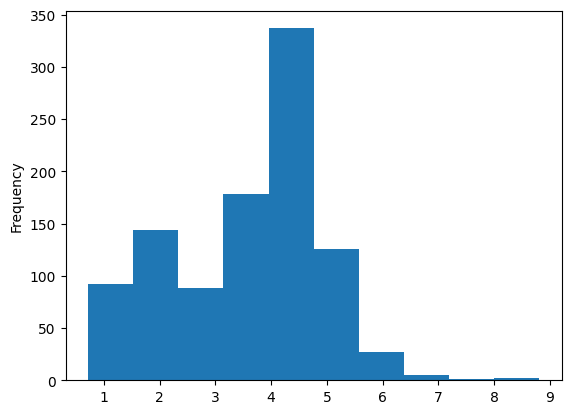

In [35]:
n_s_d['log_amt'].plot(kind='hist')

In [37]:
#split the group
n_s_d.sample(10)

,amt,is_fraud,log_amt
161958,5.52,0,1.874874
288561,74.96,0,4.330207
836320,77.03,0,4.357093
731369,76.23,0,4.346788
1220263,8.85,0,2.287471
466266,129.52,0,4.871526
987280,161.72,0,5.092031
1168607,54.85,0,4.022670
1118442,8.43,0,2.243896
1296449,53.86,0,4.004784


In [38]:
n_s_d.groupby('is_fraud')['is_fraud'].value_counts()

,count
is_fraud,
0,994
1,6


In [39]:
fraud = n_s_d [n_s_d['is_fraud'] == 1]['log_amt']
non_fraud = n_s_d [n_s_d['is_fraud'] == 0]['log_amt']

In [41]:
#runing welch's test, because the data is not normal distributed
stat, p_value = ttest_ind(fraud, non_fraud, equal_var=False)
print("T-statistic:", stat)
print("p-value:", p_value)

T-statistic: 2.748891312292342
p-value: 0.040051906648970605


In [43]:
if stat > 0 and p_value/2 < 0.05:
    print("Reject H0 → Fraud transactions have significantly higher amounts")
else:
    print("Fail to reject H0")

Reject H0 → Fraud transactions have significantly higher amounts
